In [40]:
import serial
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# CONFIGURATION
# ==========================================
PORT = "COM17"        # Change to your port
BAUD = 115200

# Robot Geometry (mm)
L1 = 26.0    # Coxa
L2 = 57.0    # Femur
L3 = 122.0   # Tibia
HIP_RADIUS = 137.5

# Servo Config
SERVO_MID_US = 1650

# CLAMP LIMITS (not range, hard stops)
HIP_MIN_US = 1000
HIP_MAX_US = 2300

KNEE_MIN_US = 1200
KNEE_MAX_US = 2300

FOOT_MIN_US = 1000
FOOT_MAX_US = 2050

# Servo Directions (1 = Normal, -1 = Reversed)
# CHANGE THESE IF JOINT MOVES WRONG WAY
HIP_DIR = 1
KNEE_DIR = 1
FOOT_DIR = -1  # REVERSED: Positive Angle -> Lower Pulse

# Leg Mounting Angles (Radians)
# Standard 6-leg radial symmetry: 0, 60, 120, 180, 240, 300
LEG_MOUNT_ANGLES = np.deg2rad([0, 60, 120, 180, 240, 300])

In [41]:
def angle_to_us(angle_deg, clamp_min, clamp_max, direction=1):
    """
    Convert angle (degrees) to microseconds using fixed rate:
    0 deg = 1650 us
    +/- 90 deg = +/- 1000 us (11.11 us/deg)
    Direction: 1 for normal, -1 for reversed axis
    Then CLAMPS to [clamp_min, clamp_max]
    """
    rate = 1000.0 / 90.0 
    # Calculate offset from mid
    delta_us = angle_deg * rate * direction
    us = SERVO_MID_US + delta_us
    
    # Debugging print for Foot (usually passed with clamp_min=FOOT_MIN_US)
    # if clamp_min == FOOT_MIN_US:
    #    print(f"DEBUG: Angle={angle_deg:.1f}, Dir={direction}, Delta={delta_us:.1f}, RawUS={us:.1f}")
    
    # Clamp
    us = max(clamp_min, min(clamp_max, us))
    return int(us)

In [42]:
def solve_fk_3d(base_yaw, angle1, angle2, angle3, l1, l2, l3):
    """
    Forward Kinematics: Calculates tip coordinate for a 3DOF leg.
    Takes SERVO angles in RADIANS (0 = 1650us).
    Returns (x, y, z) in LEG FRAME.
    """
    # Adjustment for Tibia: Servo 0 (1650) = 90 degree bend (Geometric -90/PI2)
    # So Geometric Angle = Servo Angle - PI/2
    angle3_geom = angle3 - (math.pi / 2.0)
    
    # Standard 3DOF: 
    # 1. Coxa Yaw (base_yaw) - rotates x,y plane
    # 2. Femur (angle2) - pitches up/down
    # 3. Tibia (angle3) - pitches relative to femur
    
    # Distance from hip pivot (origin) projected on XY plane
    # r = L1 + L2*cos(a2) + L3*cos(a2+a3)
    r = l1 + l2 * math.cos(angle2) + l3 * math.cos(angle2 + angle3_geom)
    
    # Z height
    # z = L2*sin(a2) + L3*sin(a2+a3)
    z = l2 * math.sin(angle2) + l3 * math.sin(angle2 + angle3_geom)
    
    # X, Y coordinates
    x = r * math.cos(base_yaw)
    y = r * math.sin(base_yaw)
    
    return x, y, z

In [43]:
def solve_ik_3d(x, y, z, l1, l2, l3):
    """
    Calculates SERVO angles (radians) for a 3DOF leg.
    x, y, z: Target coordinates in LEG FRAME 
    Returns: (base_yaw, angle1, angle2, angle3) or None
    """
    base_yaw = math.atan2(y, x)
    r_global = math.hypot(x, y)
    r_target = r_global - l1
    d_sq = r_target**2 + z**2
    d = math.sqrt(d_sq)
    
    if d > l2 + l3 or d < abs(l2 - l3):
        return None
    
    cos_knee = (l2**2 + l3**2 - d_sq) / (2 * l2 * l3)
    cos_knee = max(-1.0, min(1.0, cos_knee))
    knee_interior = math.acos(cos_knee)
    
    # Tibia Angle
    # Geometric: 0 = straight, -90 = down.
    # Servo: 1650(0) = down (90 deg bend).
    # Geom Angle = -(PI - Interior)
    # Servo Angle = Geom + PI/2; 
    angle3_geom = -(math.pi - knee_interior)
    angle3 = angle3_geom + (math.pi / 2.0)
    
    az = math.atan2(z, r_target)
    cos_offset = (l2**2 + d_sq - l3**2) / (2 * l2 * d)
    cos_offset = max(-1.0, min(1.0, cos_offset))
    femur_offset = math.acos(cos_offset)
    angle2 = az + femur_offset
    
    angle1 = 0.0
    
    return base_yaw, angle1, angle2, angle3

In [44]:
def get_servo_us_for_leg(leg_index, target_x_global, target_y_global, target_z_global):
    mount_angle = LEG_MOUNT_ANGLES[leg_index]
    hip_x = HIP_RADIUS * math.cos(mount_angle)
    hip_y = HIP_RADIUS * math.sin(mount_angle)
    dx = target_x_global - hip_x
    dy = target_y_global - hip_y
    dz = target_z_global
    
    local_x = dx * math.cos(-mount_angle) - dy * math.sin(-mount_angle)
    local_y = dx * math.sin(-mount_angle) + dy * math.cos(-mount_angle)
    local_z = dz
    
    result = solve_ik_3d(local_x, local_y, local_z, L1, L2, L3)
    if result is None:
        print(f"Leg {leg_index} Unreachable")
        return 1650, 1650, 1650
        
    base_yaw, _, angle2, angle3 = result
    
    deg_hip   = math.degrees(base_yaw)
    deg_femur = math.degrees(angle2)
    deg_tibia = math.degrees(angle3)

    us_hip = angle_to_us(deg_hip, HIP_MIN_US, HIP_MAX_US, HIP_DIR)
    us_knee = angle_to_us(deg_femur, KNEE_MIN_US, KNEE_MAX_US, KNEE_DIR)
    
    # FOOT_DIR is -1 if reversed
    us_tibia = angle_to_us(deg_tibia, FOOT_MIN_US, FOOT_MAX_US, FOOT_DIR)
    
    return us_hip, us_knee, us_tibia


In [45]:
# ==========================================
# SEND COMMANDS (EXPLICIT COORDINATES)
# ==========================================

# Define Target Coordinates (Global X, Y, Z) for each foot tip
# NOMINAL POSITION (All servos at 1650us / 0 deg / Knee at 90 deg)
leg_targets = [
    (220.50,   0.00, -122.00),  # Leg 0
    (110.25, 190.96, -122.00),  # Leg 1
    (-110.25, 190.96, -122.00), # Leg 2
    (-220.50,   0.00, -122.00), # Leg 3
    (-110.25, -190.96, -122.00),# Leg 4
    (110.25, -190.96, -122.00), # Leg 5
]

all_servo_us = []

for i in range(6):
    tx, ty, tz = leg_targets[i]
    
    # Get Servo Values
    us1, us2, us3 = get_servo_us_for_leg(i, tx, ty, tz)
    all_servo_us.extend([us1, us2, us3])
    
    print(f"Leg {i}: {us1}, {us2}, {us3}")

# Formatting the string (18 values comma separated)\n
line = ",".join(str(v) for v in all_servo_us) + "\n"

try:
    with serial.Serial(PORT, BAUD, timeout=1) as ser:
        time.sleep(2)  # Wait for Arduino reset
        ser.write(line.encode("ascii"))
        print("\nSENT:", line.strip())
except serial.SerialException as e:
    print(f"\nError opening serial port {PORT}: {e}")


In [49]:
def get_leg_points(leg_index, target_x_global, target_y_global, target_z_global):
    mount_angle = LEG_MOUNT_ANGLES[leg_index]
    
    # 1. Hip Joint (Body Frame)
    hip_x = HIP_RADIUS * math.cos(mount_angle)
    hip_y = HIP_RADIUS * math.sin(mount_angle)
    hip_z = 0
    
    # Transform Target to Local Frame
    dx = target_x_global - hip_x
    dy = target_y_global - hip_y
    dz = target_z_global
    
    local_x = dx * math.cos(-mount_angle) - dy * math.sin(-mount_angle)
    local_y = dx * math.sin(-mount_angle) + dy * math.cos(-mount_angle)
    local_z = dz
    
    # Solve IK to get angles
    result = solve_ik_3d(local_x, local_y, local_z, L1, L2, L3)
    if result is None:
        return None
        
    base_yaw, angle1, angle2, angle3 = result
    
    # Forward Kinematics for joint positions (Local Frame)
    # P0 = (0,0,0) - Hip Pivot
    p0 = (0, 0, 0)
    
    # P1 - Coxa End
    x1 = L1 * math.cos(base_yaw)
    y1 = L1 * math.sin(base_yaw)
    z1 = 0 
    
    # P2 - Femur End
    # Project to 2D plane of leg
    r2 = L1 + L2 * math.cos(angle2)
    z2 = L2 * math.sin(angle2)
    x2 = r2 * math.cos(base_yaw)
    y2 = r2 * math.sin(base_yaw)
    
    # P3 - Tibia End (Target)
    # Tibia Geom Angle = angle3 - PI/2
    angle3_geom = angle3 - (math.pi / 2.0)
    r3 = L1 + L2 * math.cos(angle2) + L3 * math.cos(angle2 + angle3_geom)
    z3 = L2 * math.sin(angle2) + L3 * math.sin(angle2 + angle3_geom)
    x3 = r3 * math.cos(base_yaw)
    y3 = r3 * math.sin(base_yaw)
    
    # Transform back to Global Frame
    def to_global(lx, ly, lz):
        gx = lx * math.cos(mount_angle) - ly * math.sin(mount_angle) + hip_x
        gy = lx * math.sin(mount_angle) + ly * math.cos(mount_angle) + hip_y
        gz = lz
        return gx, gy, gz
    
    return [to_global(*p) for p in [(0,0,0), (x1,y1,z1), (x2,y2,z2), (x3,y3,z3)]]

# VISUALIZATION
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Plot Body (Hexagon connecting hips)
hip_points = []
for i in range(6):
    angle = LEG_MOUNT_ANGLES[i]
    hip_points.append((HIP_RADIUS * math.cos(angle), HIP_RADIUS * math.sin(angle), 0))
hip_points.append(hip_points[0]) # Close loop

hx, hy, hz = zip(*hip_points)
ax.plot(hx, hy, hz, 'k-', linewidth=2, label='Body')

# Plot Legs
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i in range(6):
    tx, ty, tz = leg_targets[i]
    points = get_leg_points(i, tx, ty, tz)
    
    if points:
        px, py, pz = zip(*points)
        ax.plot(px, py, pz, '-o', color=colors[i], linewidth=2, label=f'Leg {i}')

# Axis setup
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_xlim(-400, 400)
ax.set_ylim(-400, 400)
ax.set_zlim(-200, 200)
ax.legend()

plt.show()

Connected to COM17
Starting Gait Sequence...
Move 1: Pose 0 -> Pose 1


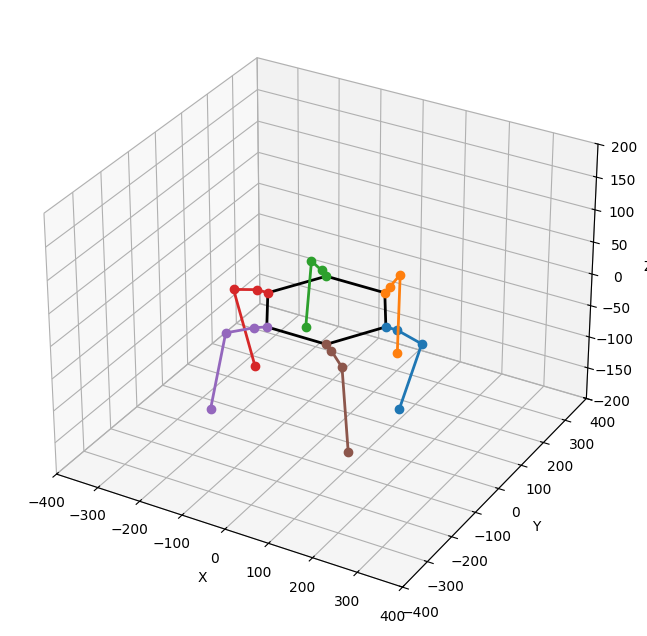

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Gait Cycle Complete.


In [68]:
# --- TRAJECTORY FUNCTION ---
def generate_line_trajectory_multi_leg(start_poses, end_poses, steps):
    """
    Generates trajectories for all 6 legs simultaneously.
    start_poses: list of 6 (x,y,z) tuples
    end_poses: list of 6 (x,y,z) tuples
    Returns: List of lists [[(x,y,z)_leg0, ...], ...] for each step
    """
    all_trajectories = []
    for i in range(6):
        traj = generate_line_trajectory(start_poses[i], end_poses[i], steps)
        all_trajectories.append(traj)
    
    # Transpose to get list of steps where each step has 6 coords
    # zip(*all_trajectories) -> iterator of tuples
    return list(zip(*all_trajectories))

# --- GAIT SEQUENCE DEFINITION ---
# P1: Home / All Down
POSE_1 = [
    (170.50, 0.00, -122.00),   # Leg 0 (Down)
    (60.25, 190.96, -122.00),  # Leg 1
    (-160.25, 190.96, -122.00),# Leg 2
    (-170.50, 0.00, -122.00),  # Leg 3
    (-160.25, -190.96, -122.00),# Leg 4
    (160.25, -190.96, -122.00) # Leg 5
]

# P2: Lift A (0, 2, 4)
POSE_2 = [
    (170.50, 0.00, -82.00),    # Leg 0 (Swing Fwd)
    (60.25, 190.96, -122.00),  # Leg 1
    (-160.25, 190.96, -82.00), # Leg 2 (Lift)
    (-170.50, 0.00, -122.00),  # Leg 3
    (-160.25, -190.96, -82.00),# Leg 4 (Lift)
    (60.25, -190.96, -122.00)  # Leg 5
]

# P3: Swing A Fwd, B Bwd
POSE_3 = [
    (270.50, 0.00, -82.00),    # Leg 0 (Lift)
    (160.25, 190.96, -122.00), # Leg 1 (Push Bwd)
    (-60.25, 190.96, -82.00),  # Leg 2 (Swing Fwd)
    (-270.50, 0.00, -122.00),  # Leg 3 (Push Bwd)
    (-60.25, -190.96, -82.00), # Leg 4 (Swing Fwd)
    (160.25, -190.96, -122.00) # Leg 5 (Push Bwd)
]

# P4: Lower A (Plant)
POSE_4 = [
    (270.50, 0.00, -122.00),   # Leg 0
    (160.25, 190.96, -122.00), # Leg 1
    (-60.25, 190.96, -122.00), # Leg 2 (Down)
    (-270.50, 0.00, -122.00),  # Leg 3
    (-60.25, -190.96, -122.00),# Leg 4 (Down)
    (60.25, -190.96, -122.00)  # Leg 5
]

# P5: Lift B (1, 3, 5)
POSE_5 = [
    (270.50, 0.00, -122.00),   # Leg 0 (Push Bwd)
    (160.25, 190.96, -82.00),  # Leg 1 (Lift)
    (-60.25, 190.96, -122.00), # Leg 2
    (-270.50, 0.00, -82.00),   # Leg 3 (Lift)
    (-60.25, -190.96, -122.00),# Leg 4
    (60.25, -190.96, -82.00)   # Leg 5 (Swing Fwd)
]

# P6: Swing B Fwd, A Bwd
POSE_6 = [
    (170.50, 0.00, -122.00),   # Leg 0
    (60.25, 190.96, -82.00),   # Leg 1 (Swing Fwd)
    (-160.25, 190.96, -122.00),# Leg 2 (Push Bwd)
    (-170.50, 0.00, -82.00),   # Leg 3 (Swing Fwd)
    (-160.25, -190.96, -122.00),# Leg 4 (Push Bwd)
    (160.25, -190.96, -82.00)  # Leg 5 (Lift)
]

# Sequence: P1 -> P2 -> P3 -> P4 -> P5 -> P6 -> P1
GAIT_SEQUENCE = [POSE_1, POSE_2, POSE_3, POSE_4, POSE_5, POSE_6, POSE_1]
STEPS_PER_MOVE = 20

# --- EXECUTION LOOP ---
# Connect to Serial (Optional)
ser = None
try:
    ser = serial.Serial(PORT, BAUD, timeout=1)
    time.sleep(2)
    print(f"Connected to {PORT}")
except:
    print("Serial not connected. Running simulation only.")

# Setup Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

def update_plot(leg_coords):
    ax.clear()
    ax.set_xlim(-400, 400)
    ax.set_ylim(-400, 400)
    ax.set_zlim(-200, 200)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Body
    hx, hy, hz = zip(*hip_points)
    ax.plot(hx, hy, hz, 'k-', linewidth=2)
    
    # Legs
    for i in range(6):
        tx, ty, tz = leg_coords[i]
        pts = get_leg_points(i, tx, ty, tz)
        if pts:
            px, py, pz = zip(*pts)
            ax.plot(px, py, pz, '-o', linewidth=2)

print("Starting Gait Sequence...")

# Loop through sequence transitions
for i in range(5):
    for seq_idx in range(len(GAIT_SEQUENCE) - 1):
        start_p = GAIT_SEQUENCE[seq_idx]
        end_p = GAIT_SEQUENCE[seq_idx + 1]
        
        print(f"Move {seq_idx+1}: Pose {seq_idx} -> Pose {seq_idx+1}")
        
        # Generate frame-by-frame points for all legs
        frames = generate_line_trajectory_multi_leg(start_p, end_p, STEPS_PER_MOVE)
        
        for frame_coords in frames:
            # frame_coords is a tuple of 6 (x,y,z) tuples
            
            # 1. Update Plot (Using Standard Indexing 0-5)
            update_plot(frame_coords)
            plt.draw()
            plt.pause(0.001)
            
            # 2. Calculate Servos (Standard Indexing 0-5)
            servos_calculated = {}
            for i in range(6):
                tx, ty, tz = frame_coords[i]
                # Calculate IK for leg i
                servos_calculated[i] = get_servo_us_for_leg(i, tx, ty, tz)

            # 3. Reorder for Serial Output
            # Map: 0, 1, 2, 5, 4, 3 (Swapping 3 and 5)
            serial_order = [0, 1, 2, 5, 4, 3]
            command_us = []
            for idx in serial_order:
                command_us.extend(servos_calculated[idx])
                
            line = ",".join(str(v) for v in command_us) + "\n"
            if ser:
                ser.write(line.encode("ascii"))
            
            # Small delay for servo speed limit
            time.sleep(0.02)

if ser:
    ser.close()
print("Gait Cycle Complete.")
